# Repeat Purchase Prediction — Phase 4: Modeling

**Goal:** Train and compare models to predict repeat purchase (binary), 
using the features engineered in Phase 3.

Models: Logistic Regression (baseline) → Random Forest → XGBoost

In [1]:
import pandas as pd

df = pd.read_pickle('../data/Processed/modeling_dataset.pkl')
print("Shape:", df.shape)
df.head()

Shape: (5252, 13)


,Customer ID,total_spend,total_quantity,num_distinct_products,avg_price_per_item,first_order_date,country,is_uk,order_month,order_dayofweek,repeat_purchase,log_total_spend,log_total_quantity
0,12346.0,45.00,10,1,4.500000,2009-12-14 08:34:00,United Kingdom,1,12,0,1,3.828641,2.397895
1,12347.0,611.53,509,40,1.834000,2010-10-31 14:20:00,Iceland,0,10,6,1,6.417598,6.234411
2,12348.0,221.16,372,19,0.704737,2010-09-27 14:59:00,Finland,0,9,0,1,5.403398,5.921578
3,12349.0,1068.52,473,46,4.230000,2010-04-29 13:20:00,Italy,0,4,3,1,6.974965,6.161207
4,12350.0,294.40,196,16,1.581250,2011-02-02 16:01:00,Norway,0,2,2,0,5.688330,5.283204


## Selecting Features for Modeling

Using behavioral, geographic, and timing features. Dropping raw identifiers 
and the un-transformed spend/quantity columns (using log versions instead).

In [2]:
feature_cols = [
    'log_total_spend', 'log_total_quantity', 'num_distinct_products',
    'avg_price_per_item', 'is_uk', 'order_month', 'order_dayofweek'
]

X = df[feature_cols]
y = df['repeat_purchase']

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts(normalize=True))

X shape: (5252, 7)
y distribution:
repeat_purchase
0    0.552551
1    0.447449
Name: proportion, dtype: float64


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print()
print("Train target distribution:", y_train.value_counts(normalize=True).to_dict())
print("Test target distribution:", y_test.value_counts(normalize=True).to_dict())

Train shape: (4201, 7)
Test shape: (1051, 7)

Train target distribution: {0: 0.552487502975482, 1: 0.44751249702451795}
Test target distribution: {0: 0.5528068506184586, 1: 0.44719314938154137}


## Model 1: Logistic Regression (Baseline)

Starting with a simple, interpretable model as our baseline before trying 
more complex models. Logistic Regression requires features to be scaled, 
since it's sensitive to feature magnitude.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression trained.")

Logistic Regression trained.


In [5]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_lr))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print()
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_lr))

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.85      0.70       581
           1       0.61      0.29      0.40       470

    accuracy                           0.60      1051
   macro avg       0.60      0.57      0.55      1051
weighted avg       0.60      0.60      0.56      1051


Confusion Matrix:
[[492  89]
 [332 138]]

ROC-AUC Score: 0.5947376130662467


## Model 2: Random Forest

Testing whether a tree-based model captures non-linear patterns and feature 
interactions better than the linear baseline.

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)  # Tree models don't need scaling

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print()
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_rf))

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.69      0.64       581
           1       0.52      0.42      0.46       470

    accuracy                           0.57      1051
   macro avg       0.56      0.55      0.55      1051
weighted avg       0.56      0.57      0.56      1051


Confusion Matrix:
[[401 180]
 [274 196]]

ROC-AUC Score: 0.5966601970190794


## Model 3: XGBoost

In [9]:
!pip install xgboost --quiet

In [10]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print()
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba_xgb))

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.66      0.63       581
           1       0.53      0.46      0.49       470

    accuracy                           0.57      1051
   macro avg       0.57      0.56      0.56      1051
weighted avg       0.57      0.57      0.57      1051


Confusion Matrix:
[[386 195]
 [253 217]]

ROC-AUC Score: 0.5963782180393307


## Model Interpretation with SHAP

Even though predictive performance is modest (ROC-AUC ~0.60), we can still 
examine which features the model relies on most — this tells us what little 
signal exists, and in what direction each feature pushes the prediction.

In [12]:
!pip install shap --quiet
import shap

In [13]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print("SHAP values computed. Shape:", shap_values.shape)

SHAP values computed. Shape: (1051, 7)


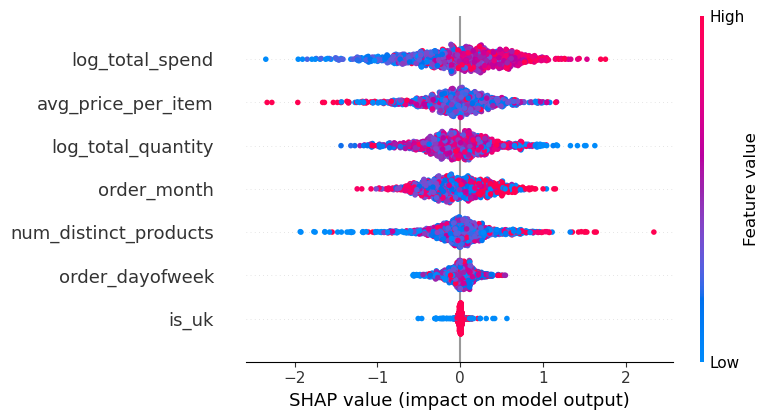

In [14]:
shap.summary_plot(shap_values, X_test, feature_names=feature_cols)

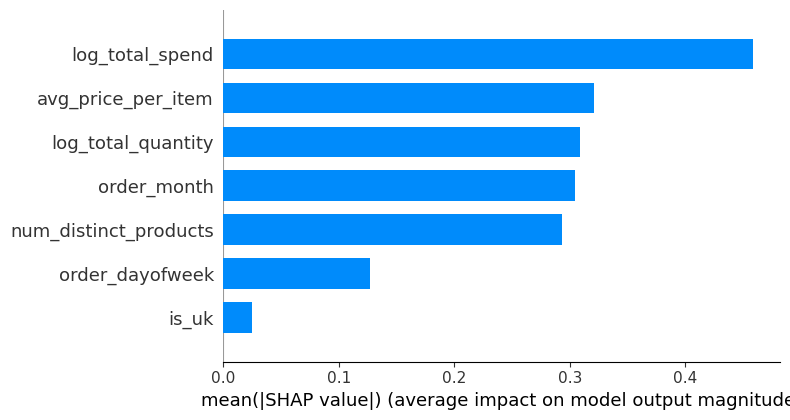

In [15]:
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, plot_type='bar')

## Exporting Data for Power BI

Exporting two tables:
1. Customer-level table with features, actual repeat purchase outcome, and 
   model-predicted probability (from XGBoost, our chosen model)
2. Transaction-level cleaned data, for revenue/category/geography visuals

In [16]:
# Get XGBoost predictions for ALL customers (not just test set) for the dashboard
xgb_full_proba = xgb.predict_proba(X)[:, 1]

export_df = df.copy()
export_df['predicted_probability'] = xgb_full_proba
export_df['predicted_repeat'] = (export_df['predicted_probability'] >= 0.5).astype(int)

# Simple risk segment for dashboard use
export_df['risk_segment'] = pd.cut(
    export_df['predicted_probability'],
    bins=[0, 0.4, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

print(export_df[['Customer ID', 'repeat_purchase', 'predicted_probability', 'predicted_repeat', 'risk_segment']].head())

export_df.to_csv('../data/Processed/customer_predictions.csv', index=False)
print("Saved customer_predictions.csv")

   Customer ID  repeat_purchase  predicted_probability  predicted_repeat  \
0      12346.0                1               0.435701                 0   
1      12347.0                1               0.734300                 1   
2      12348.0                1               0.830262                 1   
3      12349.0                1               0.689025                 1   
4      12350.0                0               0.196968                 0   

  risk_segment  
0       Medium  
1         High  
2         High  
3         High  
4          Low  
Saved customer_predictions.csv
